<a href="https://colab.research.google.com/github/prawinkailasanathan/co2emissionpredictor/blob/main/CO2Emission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [3]:
data=pd.read_csv("sustainability_data.csv")
data.head()
data.describe()

,Year,Energy_Consumption,Renewable_Percentage,GDP,CO2_Emissions
count,21.000000,21.000000,21.000000,21.000000,21.000000
mean,2010.000000,520.476190,22.630410,1480.142857,896.074054
std,6.204837,39.847985,6.862521,253.700076,54.658398
min,2000.000000,468.000000,10.324833,985.000000,792.119958
25%,2005.000000,484.000000,18.992052,1296.000000,864.651884
50%,2010.000000,517.000000,24.881291,1433.000000,883.858124
75%,2015.000000,531.000000,28.369161,1668.000000,947.372230
max,2020.000000,597.000000,29.893956,1998.000000,974.253008


In [4]:
X=data[['Year','Energy_Consumption','Renewable_Percentage','GDP',]]
y=data['CO2_Emissions']

In [5]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=48)

In [6]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(x_train)
X_poly_test = poly.transform(x_test)

In [7]:
model = LinearRegression()
model.fit(X_poly_train, y_train)

LinearRegression()

In [8]:
y_pred=model.predict(X_poly_test)

In [9]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 90928.54886012294
R² Score: -24.062885091762574


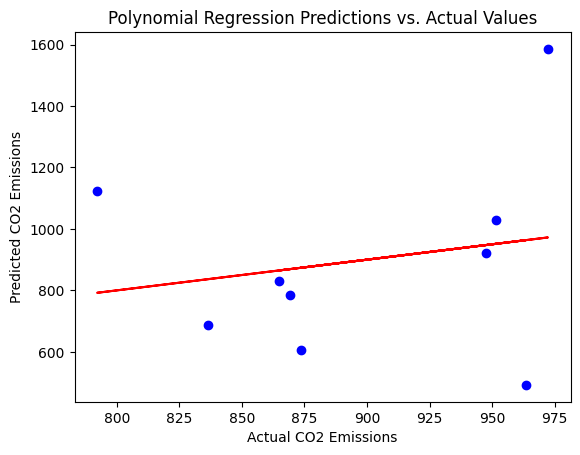

In [10]:
plt.scatter(y_test, y_pred, color='blue')
plt.plot(y_test, y_test, color='red')  # 45-degree line
plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title('Polynomial Regression Predictions vs. Actual Values')
plt.show()

In [11]:
joblib.dump(model,'polynomialRegModel.pkl')

['polynomialRegModel.pkl']